In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import LocallyLinearEmbedding # 지역적 선형 임베딩 알고리즘을 사용하기 위해 import 한다.

지역적 선형 임베딩(Locally Linear Embedding, LLE)

각 데이터 포인트의 이웃 데이터 중 k개의 이웃 데이터를 선정하고 데이터 자신과 k개의 이웃 데이터를 하나의 덩어리로 가정하고 데이터를 재수성 한다. 기존 데이터 자신의 이웃 데이를 기준으로 재구성하는 방법으로 해당 데이터 자체보다 주변의 이웃 데이터들이 중요하다.

와인 데이터를 사용해서 주성분 분석을 통해 차원을 축소해 본 후 차원을 축소하기 전과 차원을 축소한 후 정확도가 얼마나 달라지는지 알아본다.

In [2]:
# 데이터 불러오기
raw_data = datasets.load_wine() # 사이킷런 라이브러리가 제공하는 와인 데이터를 불러온다.
# print(raw_data)

# 피쳐, 레이블 데이터 저장
xData = raw_data.data # 피쳐 데이터를 저장한다.
yData = raw_data.target # 피쳐 데이터에 따른 레이블을 저장한다.
# print(xData.shape, yData.shape)

# 학습 데이터와 테스트 데이터로 분할
x_train, x_test, y_train, y_test = train_test_split(xData, yData, random_state=1)
# print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

# 데이터 표준화(정규화)
scaler = StandardScaler() # 표준화 스케일러 객체를 만든다.
x_train = scaler.fit_transform(x_train) # 학습 데이터를 표준화 스케일러로 표준화하고 적용한다.
x_test = scaler.transform(x_test) # 테스트 데이터를 학습 데이터로 표준화한 스케일러에 적용한다.

지역적 선형 임베딩을 이용한 차원 축소

In [18]:
# n_components 속성값에 축소하려는 차원 크기를 지정하고 지역적 선형 임베딩 모델을 만든다.
model_lle = LocallyLinearEmbedding(n_components=2)

# 지역적 선형 임베딩은 지도 학습적인 접근 방법이므로 표준화 스케일러로 표준화한 학습 데이터와 학습 데이터에 따른 레이블을 넘겨서 학습시킨다.
# model_lle.fit(x_train, y_train)
# 학습된 선형 판별 분석 모델에 학습 데이터를 적용한다.
# x_train_lle = model_lle.transform(x_train)
x_train_lle = model_lle.fit_transform(x_train, y_train)

# 표준화 스케일러의 사용 방법과 마찬가지로 학습은 학습 데이터로만 해야하고 테스트 데이터는 학습 데이터로 학습된 결과에 적용만 시킨다.
x_test_lle = model_lle.transform(x_test)
print(x_train.shape, x_train_lle.shape, x_test.shape, x_test_lle.shape)

(133, 13) (133, 2) (45, 13) (45, 2)


In [19]:
# 지역적 선형 임베딩 벡터 확인
# embedding_ 속성으로 상수항을 확인할 수 있다.
print(model_lle.embedding_)

[[ 0.10370077  0.03797149]
 [ 0.07222626  0.00764776]
 [ 0.11291288  0.05930921]
 [ 0.11560401  0.06205209]
 [ 0.11854756  0.06719633]
 [-0.02664269 -0.13181186]
 [-0.10501921  0.07537654]
 [-0.10326081  0.07047313]
 [ 0.10811266  0.04689056]
 [-0.04377827 -0.09418701]
 [ 0.0712414   0.01801874]
 [ 0.13033709  0.08810276]
 [ 0.02991311 -0.04069974]
 [-0.07898669  0.01497572]
 [ 0.03473125 -0.05744147]
 [ 0.01943026 -0.04529514]
 [ 0.11959649  0.07007802]
 [-0.10317351  0.07114343]
 [-0.02752016 -0.14962908]
 [-0.1164511   0.10200801]
 [ 0.10508563  0.04186687]
 [-0.01462819 -0.16313682]
 [ 0.06810266 -0.0169578 ]
 [-0.01732533 -0.16242923]
 [ 0.11454199  0.05901053]
 [-0.09625792  0.05485706]
 [-0.11013016  0.08772677]
 [-0.10843424  0.08356562]
 [-0.10619192  0.07755468]
 [-0.08729218  0.04167607]
 [-0.03682447 -0.05761368]
 [ 0.09367018  0.02624216]
 [-0.10295085  0.06762962]
 [ 0.11999055  0.07023365]
 [-0.06361883 -0.0199435 ]
 [-0.11550832  0.09903396]
 [ 0.11279934  0.05534145]
 

선형 판별 분석을 통해 차원 축소된 데이터 시각화

In [20]:
# 차원 축소된 데이터를 시각화 하기 위해서 데이터프레임을 만든다.
df = pd.DataFrame(x_train_lle, columns=['lle_x', 'lle_y'])
df['label'] = y_train
df

,lle_x,lle_y,label
0,0.103701,0.037971,0
1,0.072226,0.007648,1
2,0.112913,0.059309,0
3,0.115604,0.062052,0
4,0.118548,0.067196,0
...,...,...,...
128,-0.122468,0.117589,2
129,-0.106745,0.077409,2
130,0.001631,-0.119052,1
131,-0.111992,0.091476,2


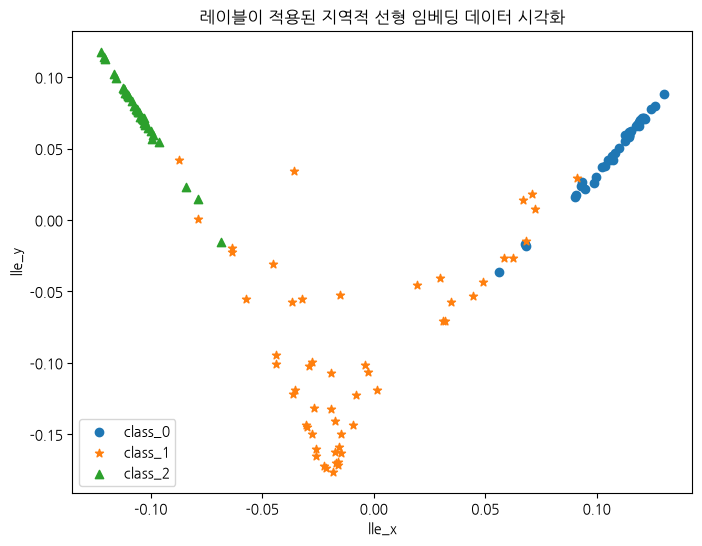

In [21]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^']

for index, marker in enumerate(markers):
    df_index = df[df.label == index]
    label = raw_data.target_names[index]
    plt.scatter(x=df_index.lle_x, y=df_index.lle_y, marker=marker, label=label)

plt.title('레이블이 적용된 지역적 선형 임베딩 데이터 시각화')
plt.xlabel('lle_x')
plt.ylabel('lle_y')
plt.legend()
plt.show()

지역적 선형 임베딩 적용 전 데이터로 학습, 예측, 평가를 실행한다.

In [22]:
# 차원 축소가 되지 않은 학습 데이터(x_train)와 차원 축소가 되지 않은 학습 데이터에 따른 레이블(y_train)을 넘겨서 랜덤 포레스트 모델을 만들고 학습시킨다.
model = RandomForestClassifier(random_state=0, max_depth=2).fit(x_train, y_train)

In [23]:
# predict() 메소드의 인수로 차원 축소가 되지 않은 테스트 데이터(x_test)를 넘겨서 서포트 벡터 머신 모델을 예측한다.
predict = model.predict(x_test)
print(predict)

[2 1 0 1 0 2 1 0 2 1 0 0 1 0 1 1 2 0 1 0 0 1 2 0 0 2 0 0 0 2 1 2 2 0 1 1 1
 1 1 0 0 1 2 0 0]


In [24]:
# predict_proba() 메소드의 인수로 차원 축소가 되지 않은 테스트 데이터(x_test)를 넘겨서 각 클래스에 속할 확률로 예측한다.
predict_proba = model.predict_proba(x_test)
print(predict_proba)

[[0.06362204 0.27662898 0.65974899]
 [0.07527785 0.87944299 0.04527917]
 [0.68984851 0.23149516 0.07865633]
 [0.08605278 0.86203798 0.05190924]
 [0.85720867 0.12172218 0.02106915]
 [0.032829   0.2083631  0.7588079 ]
 [0.13843333 0.63448642 0.22708025]
 [0.85720867 0.12172218 0.02106915]
 [0.01684088 0.17892642 0.8042327 ]
 [0.03126683 0.86376109 0.10497208]
 [0.7449743  0.17077371 0.08425198]
 [0.46182976 0.41698592 0.12118432]
 [0.08779992 0.85888405 0.05331603]
 [0.8438832  0.12503028 0.03108652]
 [0.08436322 0.81247995 0.10315683]
 [0.03396126 0.9160399  0.04999884]
 [0.10772521 0.2818495  0.61042528]
 [0.77480273 0.19092476 0.0342725 ]
 [0.08009975 0.77564044 0.14425981]
 [0.8366743  0.13382925 0.02949646]
 [0.85079023 0.12771509 0.02149468]
 [0.25611351 0.54744938 0.19643711]
 [0.06944088 0.21842478 0.71213434]
 [0.65358728 0.33730652 0.00910619]
 [0.68868517 0.26564099 0.04567383]
 [0.06833558 0.30731826 0.62434616]
 [0.84183189 0.13667343 0.02149468]
 [0.81741427 0.15772108 0.02

In [25]:
# 혼동 행렬
# confusion_matrix() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 혼동 행렬을 출력한다.
confusion = confusion_matrix(y_test, predict)
print(confusion)

[[18  0  0]
 [ 1 16  0]
 [ 0  0 10]]


In [26]:
# 분류 리포트
# classification_report() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 분류 리포트를 출력한다.
classification = classification_report(y_test, predict, target_names=raw_data.target_names)
print(classification)

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.94      0.97        17
     class_2       1.00      1.00      1.00        10

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



지역적 선형 임베딩 적용 후 데이터로 학습, 예측, 평가를 실행한다.

In [27]:
# 차원 축소가 된 학습 데이터(x_train_lle)와 차원 축소가 된 학습 데이터에 따른 레이블(y_train)을 넘겨서 앙상블 랜덤 포레스트 모델을 만들고 학습시킨다.
model.fit(x_train_lle, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [28]:
# predict() 메소드의 인수로 차원 축소가 된 테스트 데이터(x_test_lle)를 넘겨서 서포트 벡터 머신 모델을 예측한다.
predict = model.predict(x_test_lle)
print(predict)

[2 1 1 1 0 2 1 0 2 1 0 0 1 0 1 1 2 0 1 0 0 1 2 0 0 2 0 0 0 2 1 2 2 0 1 1 1
 1 1 0 0 1 2 1 0]


In [29]:
# predict_proba() 메소드의 인수로 차원 축소가 되지 않은 테스트 데이터(x_test_lle)를 넘겨서 각 클래스에 속할 확률로 예측한다.
predict_proba = model.predict_proba(x_test_lle)
print(predict_proba)

[[0.04494729 0.01049971 0.944553  ]
 [0.02609873 0.96408927 0.009812  ]
 [0.46529225 0.5029529  0.03175485]
 [0.06007542 0.92266492 0.01725967]
 [0.88658173 0.04793862 0.06547965]
 [0.20174535 0.23524129 0.56301336]
 [0.02609873 0.96408927 0.009812  ]
 [0.90225484 0.05031041 0.04743475]
 [0.17486203 0.03074627 0.7943917 ]
 [0.02609873 0.96408927 0.009812  ]
 [0.90225484 0.05031041 0.04743475]
 [0.82737161 0.04001387 0.13261452]
 [0.02609873 0.96408927 0.009812  ]
 [0.88658173 0.04793862 0.06547965]
 [0.02609873 0.96408927 0.009812  ]
 [0.02609873 0.96408927 0.009812  ]
 [0.04494729 0.01049971 0.944553  ]
 [0.89644207 0.04877195 0.05478598]
 [0.02609873 0.96408927 0.009812  ]
 [0.88658173 0.04793862 0.06547965]
 [0.89644207 0.04877195 0.05478598]
 [0.02609873 0.96408927 0.009812  ]
 [0.18472236 0.0315796  0.78369803]
 [0.88658173 0.04793862 0.06547965]
 [0.89858817 0.05554851 0.04586332]
 [0.04494729 0.01049971 0.944553  ]
 [0.90225484 0.05031041 0.04743475]
 [0.89644207 0.04877195 0.05

In [30]:
# 혼동 행렬
# confusion_matrix() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 혼동 행렬을 출력한다.
confusion = confusion_matrix(y_test, predict)
print(confusion)

[[16  2  0]
 [ 1 16  0]
 [ 0  0 10]]


In [31]:
# 분류 리포트
# classification_report() 함수의 인수로 테스트 데이터의 레이블(y_test)과 예측값(predict)을 순서대로 넘겨서 분류 리포트를 출력한다.
classification = classification_report(y_test, predict, target_names=raw_data.target_names)
print(classification)

              precision    recall  f1-score   support

     class_0       0.94      0.89      0.91        18
     class_1       0.89      0.94      0.91        17
     class_2       1.00      1.00      1.00        10

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.93      0.93      0.93        45

